# **Problema 4: Estimación de parámetros con PINNs**

Un grupo de Laboratorio 5 elige hacer la mejor práctica de la materia: Fluidos.
En esta práctica, se introduce un agitador magnético para generar un vórtice dentro de un recipiente cilíndrico y se usa el método velocimetría de imágenes de partículas (PIV, por sus siglas en inglés).
Esto permite medir el campo de velocidades $\mathbf{u}(\mathbf{x}, t)$ sobre la superficie, habitualmente modelado mediante el vórtice de Burgers
$$ \mathbf{u}_B(\mathbf{x}, t) = -\alpha r \mathbf{\hat{r}} + \frac{\Gamma}{2\pi r}\left[1 - \exp\left(-r^2/r_0^2\right)\right]\boldsymbol{\hat{\theta}} + 2\alpha z\mathbf{\hat{z}} $$

donde $\Gamma$ es la circulación asintótica del vórtice, $\alpha$ un parámetro que controla el flujo radial y $r_0 = \alpha / 2\nu$ un radio característico del vórtice controlado por la velocidad y la viscosidad.
Dado que se mira la superficie, la componente $z$ suele ignorarse por completo.

Sin embargo, las cámaras de alta velocidad necesarias para hacer PIV no funcionan y no pudieron ser reemplazadas por cuestiones presupuestarias. Ante la desesperación, el grupo decide introducir una pequeña bolita de polietileno dentro del flujo y grabarla con un celular.
Luego, el grupo elige algunos de los cuadros del video donde tanto el centro del vórtice cómo la bolita se ven claramente y, muy laboriosamente, determinan la posición relativa de ambos.
Estos datos se encuentran en el archivo `posiciones.txt`, con la posición $\mathbf{X}(t)$ (en cartesianas) de la boltia respecto al vórtice (que se considera en el origen) para los $t$ indicados. Las distancias están medidas en centimetros y el tiempo en segundos.

Entrene una PINN que ajuste la trayectoria mediante el modelo de Burgers $\dot{\mathbf{X}} = \mathbf{u}_B(\mathbf{X}, t)$ y aprenda los parámetros $\alpha$, $\Gamma$ y $r_0$. La predicción de la PINN debe coincidir con los datos provistos en una trayectoria aproximadamente espiralada, cómo mínimo. Puede usar el siguiente esqueleto, que además contiene estimaciones del orden de magnitud de los distintos parámetros hechos por el grupo. Los parámetros propuestos no son necesariamente óptimos, es libre de cambiarlos todos.

**Nota:** Por simplicidad, ignoraremos los errores en la medición de estos datos, pero podrían incluirse cómo un término adicional de la función de pérdida.

In [148]:
import numpy as np
import matplotlib.pyplot as plt
import torch

# Cargar datos
!pip install -q gdown
!gdown 1USjbT0fCDREgM0KIFsn_9JCvcA7jBXuD -O posiciones.txt

t_data, x_data, y_data = np.loadtxt("posiciones.txt", unpack=True)




[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
Downloading...
From: https://drive.google.com/uc?id=1USjbT0fCDREgM0KIFsn_9JCvcA7jBXuD
To: c:\Users\User\Desktop\Fisica-de-Fluidos-E1\trabjo E1\posiciones.txt

  0%|          | 0.00/1.52k [00:00<?, ?B/s]
100%|██████████| 1.52k/1.52k [00:00<00:00, 11.5MB/s]


Voy a querer armarme una PINN que contenga dentro de su funcion de perdida fisica el modelo de vorticidad de Burgers, sin embargo el fordward necesario debe ser necesariamente los parametros a controlar, de modo que el sistema aprenda a "elejir" estos parametros

In [149]:
import torch
import numpy as np
import matplotlib.pyplot as plt

#Vengo con la PINN del P3 y le hago modificaciones
class PINN(torch.nn.Module):
    def __init__(self, hidden_sizes=[32,32,32]):
        super().__init__()
        layers = [1] + hidden_sizes + [2] #le doy 2 parametros de salida, r y theta
        self.layers = torch.nn.ModuleList()
        for i in range(len(layers)-1):
            self.layers.append(torch.nn.Linear(layers[i], layers[i+1]))

        self.alpha=torch.nn.Parameter(torch.tensor([0.1]))
        self.Gamma=torch.nn.Parameter(torch.tensor([10.0]))
        self.r0=torch.nn.Parameter(torch.tensor([1.0]))

        self.loss_history=[]
        self.loss_data_history=[]
        self.loss_phys_history=[]

    def forward(self,t):
        x=t
        for layer in self.layers[:-1]: x=torch.sigmoid(layer(x))
        return self.layers[-1](x)

    def data_loss(self,t_data,rtheta_data):
        return torch.mean((self.forward(t_data)-rtheta_data)**2)

    def burgers_rhs(self,r):
        drdt=-self.alpha*r
        dthetadt=(self.Gamma/(2*torch.pi*r**2))*(1-torch.exp(-(r**2)/(self.r0**2)))
        return drdt,dthetadt

    def physics_loss(self,t_phys):
        t_phys=t_phys.requires_grad_(True)
    
        pred=self.forward(t_phys)
        r=pred[:,0:1]
        theta=pred[:,1:2]
    
        drdt=torch.autograd.grad(
            r,t_phys,
            grad_outputs=torch.ones_like(r),
            create_graph=True
        )[0]
    
        dthetadt=torch.autograd.grad(
            theta,t_phys,
            grad_outputs=torch.ones_like(theta),
            create_graph=True
        )[0]
    
        drdt_rhs,dthetadt_rhs=self.burgers_rhs(r)
    
        res_r=drdt-drdt_rhs
        res_theta=dthetadt-dthetadt_rhs
    
        return torch.mean(res_r**2+res_theta**2)

    def total_loss(self,t_data,rtheta_data,t_phys,lambda_phys):
        ld=self.data_loss(t_data,rtheta_data)
        lp=self.physics_loss(t_phys)
        return ld+lambda_phys*lp,ld,lp

    def train_pinn(self,t_data,rtheta_data,t_phys,epochs=20000,lr=1e-3,lambda_phys=1e-2):
        optimizer=torch.optim.Adam(self.parameters(),lr=lr)
        for epoch in range(epochs):
            optimizer.zero_grad()
            loss,ld,lp=self.total_loss(t_data,rtheta_data,t_phys,lambda_phys)
            loss.backward()
            optimizer.step()
            self.loss_history.append(loss.item())
            self.loss_data_history.append(ld.item())
            self.loss_phys_history.append(lp.item())
            if epoch%2000==0:
                print(f"epoch {epoch:5d} | total {loss.item():.3e} | data {ld.item():.3e} | phys {lp.item():.3e}")
        print("\nEntrenamiento terminado\n")
        print("alpha =",self.alpha.item())
        print("Gamma =",self.Gamma.item())
        print("r0 =",self.r0.item())

    def plot_loss(self):
        plt.figure(figsize=(8,5))
        plt.plot(self.loss_history,label="total")
        plt.plot(self.loss_data_history,label="data")
        plt.plot(self.loss_phys_history,label="physics")
        plt.yscale("log")
        plt.xlabel("epoch")
        plt.ylabel("loss")
        plt.legend()
        plt.grid()
        plt.show()

In [150]:
t_data, x_data, y_data = np.loadtxt("posiciones.txt", unpack=True)

# Convierto a r(t), θ(t)

r_data = np.sqrt(x_data**2 + y_data**2)
theta_data = np.arctan2(y_data, x_data)

t_data = torch.tensor(t_data[:,None], dtype=torch.float32)
rtheta_data = torch.tensor(np.stack([r_data,theta_data],axis=1), dtype=torch.float32)

t_phys = torch.linspace(t_data.min(), t_data.max(), 200).reshape(-1,1)

epoch     0 | total 9.203e+00 | data 9.201e+00 | phys 2.477e+00
epoch  2000 | total 1.719e+00 | data 1.719e+00 | phys 1.453e-02
epoch  4000 | total 1.054e+00 | data 1.040e+00 | phys 1.367e+01
epoch  6000 | total 5.528e-01 | data 5.269e-01 | phys 2.592e+01
epoch  8000 | total 7.356e-02 | data 2.465e-02 | phys 4.891e+01
epoch 10000 | total 6.179e-02 | data 8.001e-03 | phys 5.379e+01
epoch 12000 | total 5.994e-02 | data 6.444e-03 | phys 5.350e+01
epoch 14000 | total 5.784e-02 | data 5.150e-03 | phys 5.269e+01
epoch 16000 | total 5.603e-02 | data 3.859e-03 | phys 5.217e+01
epoch 18000 | total 5.487e-02 | data 3.101e-03 | phys 5.177e+01

Entrenamiento terminado

alpha = 0.02391921356320381
Gamma = -5.3616790771484375
r0 = 0.9444811940193176


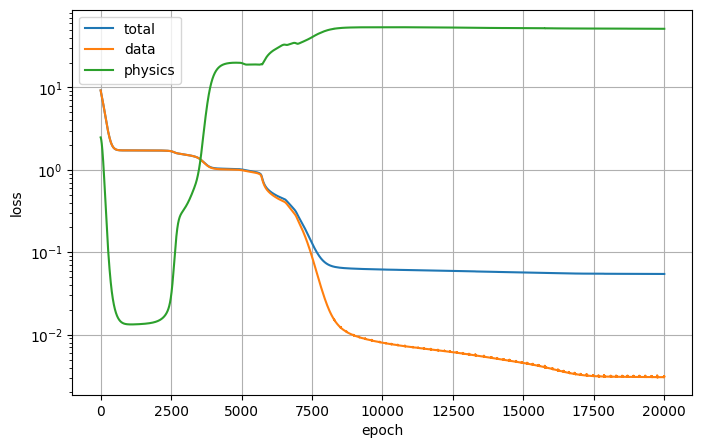

In [151]:
model = PINN([10,15,10])

model.train_pinn(
    t_data,
    rtheta_data,
    t_phys,
    epochs=20000,
    lr=1e-3,
    lambda_phys=1e-3
)

model.plot_loss()

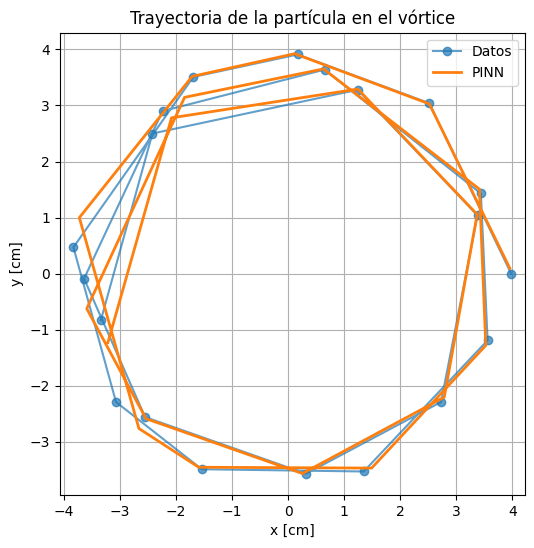

In [152]:
with torch.no_grad():

    pred = model.forward(t_data)

r_pred = pred[:,0].numpy()
theta_pred = pred[:,1].numpy()

x_pred = r_pred*np.cos(theta_pred)
y_pred = r_pred*np.sin(theta_pred)

plt.figure(figsize=(6,6))

plt.plot(x_data, y_data, 'o-', label="Datos", alpha=0.7)
plt.plot(x_pred, y_pred, '-', label="PINN", linewidth=2)

plt.xlabel("x [cm]")
plt.ylabel("y [cm]")
plt.title("Trayectoria de la partícula en el vórtice")
plt.axis("equal")
plt.grid(True)
plt.legend()

plt.show()

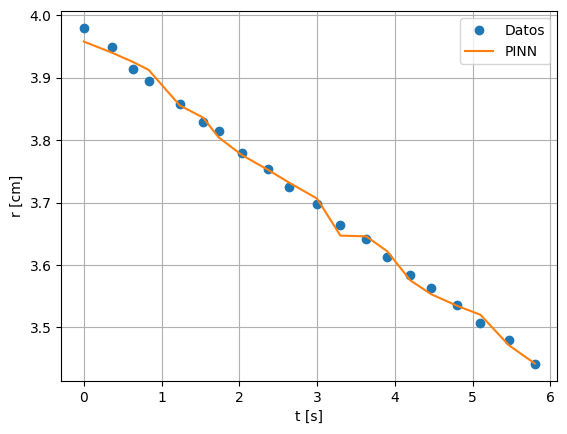

In [153]:
plt.figure()

plt.plot(t_data.numpy(), r_data, 'o', label="Datos")
plt.plot(t_data.numpy(), r_pred, '-', label="PINN")

plt.xlabel("t [s]")
plt.ylabel("r [cm]")
plt.grid(True)
plt.legend()

plt.show()

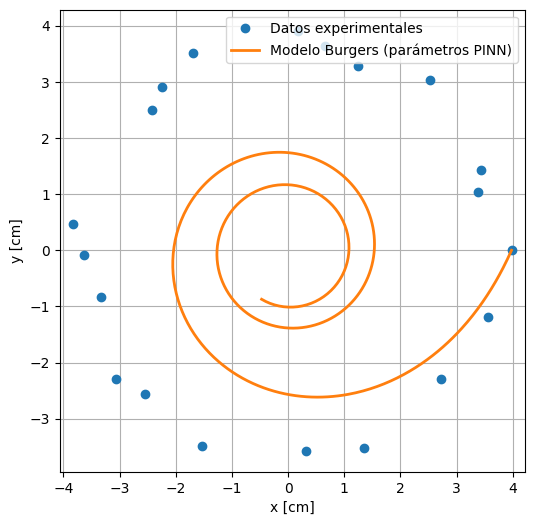

In [154]:
alpha = model.alpha.item()
Gamma = model.Gamma.item()
r0 = model.r0.item()

t_sim = np.linspace(t_data[0].item(), 10*t_data[-1].item(), 400)

dt = t_sim[1]-t_sim[0]

r_sim = np.zeros_like(t_sim)
theta_sim = np.zeros_like(t_sim)

r_sim[0] = r_data[0]
theta_sim[0] = theta_data[0]

for i in range(len(t_sim)-1):

    r = r_sim[i]

    drdt = -alpha*r
    dthetadt = (Gamma/(2*np.pi*r**2))*(1-np.exp(-(r**2)/(r0**2)))

    r_sim[i+1] = r + drdt*dt

    theta_sim[i+1] = theta_sim[i] + dthetadt*dt

x_sim = r_sim*np.cos(theta_sim)
y_sim = r_sim*np.sin(theta_sim)

plt.figure(figsize=(6,6))

plt.plot(x_data, y_data, 'o', label="Datos experimentales")
plt.plot(x_sim, y_sim, '-', label="Modelo Burgers (parámetros PINN)", linewidth=2)

plt.xlabel("x [cm]")
plt.ylabel("y [cm]")
plt.axis("equal")
plt.grid(True)
plt.legend()

plt.show()